# ML4Sci GSoC 2026 — Test VII: Physics-Guided ML
## Physics-Informed Neural Network for Gravitational Lens Classification
**Author:** Parv Patel | IIT Palakkad

**Dataset structure:**
```
dataset/
  train/
    no/       → class 0  (no substructure)
    sphere/   → class 1  (subhalo / sphere substructure)
    vort/     → class 2  (vortex substructure)
  val/
    no/ | sphere/ | vort/    ← final ROC-AUC evaluation
```
**Primary Metric:** ROC-AUC (One-vs-Rest, macro-averaged)

## The Physics: Gravitational Lensing Equation

The **gravitational lens equation** relates the true source position **β** to the observed image position **θ**:

$$\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}(\boldsymbol{\theta})$$

where the deflection angle **α** is derived from the lensing potential ψ:

$$\boldsymbol{\alpha} = \nabla\psi$$

The lensing potential satisfies the **Poisson equation**:

$$\nabla^2 \psi = 2\kappa$$

where **κ (convergence)** = Σ/Σ_cr is the projected surface mass density. From ψ we also derive:

| Quantity | Formula | Physical Meaning |
|---|---|---|
| Convergence | κ = (ψ_xx + ψ_yy)/2 | Isotropic focusing (mass density) |
| Shear γ₁ | (ψ_xx − ψ_yy)/2 | Anisotropic distortion |
| Shear γ₂ | ψ_xy | Rotational shear |
| Magnification | μ = 1/[(1−κ)²−γ²] | Total flux amplification |

### Why these discriminate substructure classes:
- **No substructure** → smooth κ map, regular symmetric shear field
- **Subhalo clumps** → sharp localised κ peaks, irregular shear
- **Vortex** → rotational asymmetry in γ₂, non-monotonic magnification

### PINN Architecture
```
Input Image (224×224)
       │
       ▼
 ╔═══════════════╗
 ║ ConvergenceNet ║  ← U-Net, predicts κ̂ map
 ╚═══════════════╝
       │  κ̂ map (B,1,H,W)  [Softplus → κ ≥ 0]
       ▼
 ╔══════════════════════════════════╗
 ║  PhysicsLayer  (DIFFERENTIABLE) ║
 ║  ∇²ψ = 2κ  → FFT Poisson solve  ║
 ║  α = ∇ψ    → deflection angles  ║
 ║  β = θ − α → source reconstruct ║
 ║  γ, μ      → shear & magnif.    ║
 ╚══════════════════════════════════╝
       │  physics maps (B,5,H,W): [κ, γ₁, γ₂, |α|, μ]
       ▼
 ╔═══════════════════════════════════════════╗
 ║  DualFusion Classifier                   ║
 ║  EfficientNet-B3(image) + CNN(phys maps) ║
 ║  → Gated fusion → Softmax               ║
 ╚═══════════════════════════════════════════╝

Loss = CrossEntropy  +  λ × PhysicsConsistencyLoss
                         (TV of reconstructed source)
```

All operations in PhysicsLayer are differentiable — gradients flow through the physics back into ConvergenceNet during training.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

import warnings; warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
CONFIG = {
    'data_dir'          : '/kaggle/input/datasets/parvptl/gsoc-2026/dataset',   
    'class_names'       : ['no', 'sphere', 'vort'],
    'display_names'     : ['No Substructure', 'Sphere/Subhalo', 'Vortex'],

    # ── Model / Training ───────────────────────────────────────
    'img_size'          : 224,
    'batch_size'        : 16,   # smaller: PINN forward pass is heavier
    'num_classes'       : 3,
    'epochs'            : 35,
    'lr'                : 2e-4,
    'weight_decay'      : 1e-4,
    'internal_val_split': 0.15, # carved from train/ for early stopping only
    'num_workers'       : 2,
    'patience'          : 8,
    # Physics loss weight
    'lambda_phys'       : 0.1,
    'tta_n'             : 8,
    'save_path'         : 'best_pinn.pth',
}

## 1. Dataset

In [3]:
class LensDataset(Dataset):
    MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __init__(self, file_paths, labels, img_size=224, augment=False):
        self.file_paths = file_paths
        self.labels     = labels
        self.img_size   = img_size
        self.augment    = augment

    def __len__(self): return len(self.file_paths)

    def _load(self, path):
        ext = Path(path).suffix.lower()
        if ext == '.npy':
            arr = np.clip(np.load(path).astype(np.float32), 0.0, 1.0)
            if arr.ndim == 2: arr = np.stack([arr]*3, axis=0)
            elif arr.ndim == 3:
                if arr.shape[0] in (1,3):
                    if arr.shape[0]==1: arr=np.repeat(arr,3,0)
                else:
                    arr=arr.transpose(2,0,1)
                    if arr.shape[0]==1: arr=np.repeat(arr,3,0)
            t = torch.from_numpy(arr)
        else:
            from PIL import Image
            t = transforms.functional.to_tensor(Image.open(path).convert('RGB'))
        return transforms.functional.resize(
            t, [self.img_size]*2,
            interpolation=transforms.InterpolationMode.BILINEAR, antialias=True)

    def _augment(self, t):
        if torch.rand(1)>0.5: t=transforms.functional.hflip(t)
        if torch.rand(1)>0.5: t=transforms.functional.vflip(t)
        t=torch.rot90(t, torch.randint(0,4,(1,)).item(), dims=[1,2])
        return t

    def __getitem__(self, idx):
        raw = self._load(self.file_paths[idx])
        if self.augment: raw = self._augment(raw)
        # Return BOTH raw [0,1] (for physics layer) AND normalised (for backbone)
        normalised = (raw - self.MEAN) / self.STD
        return normalised, raw, self.labels[idx]


def collect_files(split_dir, class_names, tag=''):
    fps, labs = [], []
    print(f'Loading {tag}:')
    for i, cls in enumerate(class_names):
        d = Path(split_dir)/cls
        if not d.exists(): print(f'  WARNING: {d} not found'); continue
        found = list(d.rglob('*.npy'))+list(d.rglob('*.png'))+list(d.rglob('*.jpg'))
        fps.extend([str(f) for f in found]); labs.extend([i]*len(found))
        print(f'  {cls:>10}: {len(found):>6} samples')
    print(f'  Total: {len(fps)}\n')
    return fps, labs

In [4]:
root = Path(CONFIG['data_dir'])

tr_fps_all, tr_labs_all = collect_files(root/'train', CONFIG['class_names'], 'train/')
val_fps,    val_labs    = collect_files(root/'val',   CONFIG['class_names'], 'val/')

# Carve 15% of train/ as internal split for early stopping only
tr_fps, split_fps, tr_labs, split_labs = train_test_split(
    tr_fps_all, tr_labs_all,
    test_size=CONFIG['internal_val_split'],
    stratify=tr_labs_all, random_state=SEED)

print(f'Train: {len(tr_fps)} | Split (early stop): {len(split_fps)} | Val: {len(val_fps)}')

train_ds = LensDataset(tr_fps,    tr_labs,    CONFIG['img_size'], augment=True)
split_ds = LensDataset(split_fps, split_labs, CONFIG['img_size'], augment=False)
val_ds   = LensDataset(val_fps,   val_labs,   CONFIG['img_size'], augment=False)

cc      = np.bincount(tr_labs)
sampler = WeightedRandomSampler([1.0/cc[y] for y in tr_labs], len(tr_labs), replacement=True)
nw      = CONFIG['num_workers']

train_loader = DataLoader(train_ds, CONFIG['batch_size'], sampler=sampler,  num_workers=nw, pin_memory=True)
split_loader = DataLoader(split_ds, CONFIG['batch_size'], shuffle=False,    num_workers=nw, pin_memory=True)
val_loader   = DataLoader(val_ds,   CONFIG['batch_size'], shuffle=False,    num_workers=nw, pin_memory=True)

Loading train/:
          no:  10000 samples
      sphere:  10000 samples
        vort:  10000 samples
  Total: 30000

Loading val/:
          no:   2500 samples
      sphere:   2500 samples
        vort:   2500 samples
  Total: 7500

Train: 25500 | Split (early stop): 4500 | Val: 7500


## 2. The Physics Layer — Fully Differentiable Lensing Equation

In [5]:
class PhysicsLayer(nn.Module):
    """
    Differentiable implementation of the gravitational lensing equations.

    Given a predicted convergence map κ̂ (from ConvergenceNet), this layer:

    Step 1 — Solve the Poisson equation via 2D FFT:
        ∇²ψ = 2κ   →   ψ̂(k) = -2κ̂(k) / (kx² + ky²)
        (DC component set to zero — fixes the arbitrary constant in ψ)

    Step 2 — Deflection angles via spectral differentiation:
        α_x = ∂ψ/∂x  →  α̂_x(k) = i·kx·ψ̂(k)
        α_y = ∂ψ/∂y  →  α̂_y(k) = i·ky·ψ̂(k)

    Step 3 — Apply the lens equation:
        β = θ − α   (map image plane → source plane)

    Step 4 — Reconstruct source via differentiable bilinear sampling:
        I_src(β) = grid_sample(I_obs, β)

    Step 5 — Shear and magnification:
        κ_recon = (ψ_xx + ψ_yy) / 2
        γ₁      = (ψ_xx − ψ_yy) / 2
        γ₂      = ψ_xy
        μ       = 1 / [(1−κ)² − γ₁² − γ₂²]  (clipped for stability)

    All operations are differentiable → gradients flow through the physics
    back into ConvergenceNet weights during training.
    """

    def __init__(self, img_size=224):
        super().__init__()
        H, W = img_size, img_size

        # Pre-compute frequency grids (not learned — pure physics)
        ky = torch.fft.fftfreq(H) * 2 * 3.141592653589793
        kx = torch.fft.fftfreq(W) * 2 * 3.141592653589793
        KX, KY = torch.meshgrid(kx, ky, indexing='xy')
        K2 = KX**2 + KY**2
        K2[0, 0] = 1.0   # avoid DC division by zero

        self.register_buffer('KX', KX)
        self.register_buffer('KY', KY)
        self.register_buffer('K2', K2)

        # Coordinate grid θ in [-1, 1] for grid_sample
        y = torch.linspace(-1, 1, H)
        x = torch.linspace(-1, 1, W)
        grid_y, grid_x = torch.meshgrid(y, x, indexing='ij')
        theta = torch.stack([grid_x, grid_y], dim=-1)   # (H,W,2)
        self.register_buffer('theta', theta)

    def forward(self, kappa, image_raw):
        """
        kappa     : (B,1,H,W) predicted convergence map, values ≥ 0
        image_raw : (B,3,H,W) original image in [0,1]
        Returns:
            physics_maps : (B,5,H,W)  [κ, γ₁, γ₂, |α|, μ]
            source_recon : (B,3,H,W)  reconstructed source
        """
        B = kappa.shape[0]

        # Step 1: Poisson solve in Fourier space
        kappa_sq  = kappa.squeeze(1)                          # (B,H,W)
        kappa_hat = torch.fft.fft2(kappa_sq)
        psi_hat   = -2.0 * kappa_hat / self.K2
        psi_hat[:, 0, 0] = 0.0                               # zero DC

        # Step 2: Deflection angles
        j = torch.tensor(0+1j, dtype=torch.complex64, device=kappa.device)
        alpha_x = torch.fft.ifft2(j * self.KX * psi_hat).real
        alpha_y = torch.fft.ifft2(j * self.KY * psi_hat).real
        alpha_x = torch.tanh(alpha_x) * 0.3
        alpha_y = torch.tanh(alpha_y) * 0.3

        # Step 3: Lens equation β = θ − α
        theta = self.theta.unsqueeze(0).expand(B,-1,-1,-1)
        beta  = torch.stack([
            (theta[...,0] - alpha_x).clamp(-1,1),
            (theta[...,1] - alpha_y).clamp(-1,1)
        ], dim=-1)

        # Step 4: Reconstruct source
        source_recon = F.grid_sample(
            image_raw, beta, mode='bilinear',
            padding_mode='reflection', align_corners=True)

        # Step 5: Shear and magnification
        psi_xx      = torch.fft.ifft2(-self.KX**2 * psi_hat).real
        psi_yy      = torch.fft.ifft2(-self.KY**2 * psi_hat).real
        psi_xy      = torch.fft.ifft2(-self.KX*self.KY * psi_hat).real
        kappa_recon = (psi_xx + psi_yy) / 2.0
        gamma1      = (psi_xx - psi_yy) / 2.0
        gamma2      = psi_xy
        gamma_sq    = gamma1**2 + gamma2**2
        denom       = (1 - kappa_recon)**2 - gamma_sq
        mu          = (1.0 / (denom.abs().clamp(min=1e-3) * denom.sign().clamp(min=0) + 1e-3)).clamp(-10,10)
        alpha_mag   = (alpha_x**2 + alpha_y**2).sqrt()

        def to_map(x): return x.unsqueeze(1)
        physics_maps = torch.cat([
            to_map(kappa_recon), to_map(gamma1), to_map(gamma2),
            to_map(alpha_mag),   to_map(mu),
        ], dim=1)   # (B,5,H,W)

        return physics_maps, source_recon

## 3. ConvergenceNet — Predicts κ Map from Image

In [6]:
class ConvergenceNet(nn.Module):
    """
    U-Net encoder-decoder that predicts the convergence map κ̂(x,y).
    κ is a 2D spatial field representing projected mass density.
    Softplus output enforces the physical constraint κ ≥ 0.
    """
    def __init__(self):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1),
                nn.BatchNorm2d(cout), nn.GELU()
            )

        # Encoder
        self.enc1 = block(3,  32)
        self.enc2 = nn.Sequential(nn.MaxPool2d(2), block(32,  64))
        self.enc3 = nn.Sequential(nn.MaxPool2d(2), block(64,  128))
        self.enc4 = nn.Sequential(nn.MaxPool2d(2), block(128, 256))

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.MaxPool2d(2), block(256, 512),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            block(512, 256),
        )

        # Decoder with skip connections
        self.dec4 = nn.Sequential(block(512, 128),
                                   nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True))
        self.dec3 = nn.Sequential(block(256, 64),
                                   nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True))
        self.dec2 = nn.Sequential(block(128, 32),
                                   nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True))
        self.dec1 = block(64, 16)

        # Output: κ ≥ 0 enforced by Softplus
        self.head = nn.Sequential(nn.Conv2d(16, 1, 1), nn.Softplus())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        b  = self.bottleneck(e4)
        d4 = self.dec4(torch.cat([b,  e4], dim=1))
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d1 = self.dec1(torch.cat([d2, e1], dim=1))
        return self.head(d1)   # (B,1,H,W), κ ≥ 0

## 4. Physics Feature Encoder + Full PINN Classifier

In [7]:
class PhysicsFeatureEncoder(nn.Module):
    """Small CNN that encodes the 5-channel physics maps [κ,γ₁,γ₂,|α|,μ] into a feature vector."""
    def __init__(self, out_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(5, 32, 3, padding=1), nn.BatchNorm2d(32), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.AdaptiveAvgPool2d((4,4)),
            nn.Flatten(),
            nn.Linear(128*16, out_dim), nn.GELU(), nn.Dropout(0.3),
        )
    def forward(self, x): return self.net(x)


class LensPINN(nn.Module):
    """
    Full Physics-Informed Neural Network for gravitational lens classification.

    Three learned components:
      1. ConvergenceNet  → predicts κ̂ map (mass distribution)
      2. PhysicsLayer    → applies lensing equations (no learned params)
      3. DualFusion      → EfficientNet-B3(image) + PhysicsEncoder(κ,γ,μ) → class

    Two loss terms:
      L_total = L_cls  +  λ · L_phys
      L_cls   = CrossEntropy
      L_phys  = TV(reconstructed source) + smoothness(κ)
    """
    def __init__(self, num_classes, img_size=224, phys_dim=256):
        super().__init__()

        self.convergence_net = ConvergenceNet()
        self.physics_layer   = PhysicsLayer(img_size)
        self.phys_encoder    = PhysicsFeatureEncoder(out_dim=phys_dim)

        # EfficientNet-B3 spatial branch
        eff = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        for name, p in eff.named_parameters():
            if 'features.0' in name or 'features.1' in name:
                p.requires_grad = False
        spatial_dim = eff.classifier[1].in_features   # 1536
        eff.classifier = nn.Identity()
        self.spatial_enc  = eff
        self.spatial_drop = nn.Dropout(0.4)

        # Gated fusion + head
        fused = spatial_dim + phys_dim   # 1792
        self.gate = nn.Sequential(nn.Linear(fused, fused), nn.Sigmoid())
        self.classifier = nn.Sequential(
            nn.Linear(fused, 512), nn.GELU(), nn.BatchNorm1d(512),
            nn.Dropout(0.3), nn.Linear(512, num_classes)
        )

    def forward(self, img_norm, img_raw):
        """
        img_norm : (B,3,H,W) ImageNet-normalised  → spatial backbone
        img_raw  : (B,3,H,W) [0,1] pixel values   → convergence net + physics layer
        """
        kappa                    = self.convergence_net(img_raw)
        phys_maps, source_recon  = self.physics_layer(kappa, img_raw)
        phys_feat                = self.phys_encoder(phys_maps)
        spatial_feat             = self.spatial_drop(self.spatial_enc(img_norm))
        fused  = torch.cat([spatial_feat, phys_feat], dim=1)
        gated  = self.gate(fused) * fused
        logits = self.classifier(gated)
        return logits, source_recon, kappa


model = LensPINN(CONFIG['num_classes'], CONFIG['img_size']).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
trn   = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params → Total: {total:,} | Trainable: {trn:,} ({100*trn/total:.1f}%)')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 167MB/s]


Params → Total: 18,983,756 | Trainable: 18,979,092 (100.0%)


## 5. Loss Functions

In [8]:
def total_variation(img):
    """
    Total Variation of the reconstructed source image.

    Physics argument: a correctly predicted κ, when applied via
    β = θ − ∇ψ, should reconstruct a compact, smooth source galaxy.
    If κ is wrong, reconstruction is chaotic → high TV.
    Minimising TV forces the network to predict physically consistent κ maps.
    """
    dy = (img[:,:,1:,:] - img[:,:,:-1,:]).abs().mean()
    dx = (img[:,:,:,1:] - img[:,:,:,:-1]).abs().mean()
    return dx + dy


def kappa_smoothness(kappa):
    """Mild regularisation on κ map — penalises spurious spikes."""
    dy = (kappa[:,:,1:,:] - kappa[:,:,:-1,:]).abs().mean()
    dx = (kappa[:,:,:,1:] - kappa[:,:,:,:-1]).abs().mean()
    return (dx + dy) * 0.01


criterion_cls = nn.CrossEntropyLoss(label_smoothing=0.05)


def compute_loss(logits, source_recon, kappa, labels):
    L_cls   = criterion_cls(logits, labels)
    L_phys  = total_variation(source_recon) + kappa_smoothness(kappa)
    L_total = L_cls + CONFIG['lambda_phys'] * L_phys
    return L_total, L_cls.item(), L_phys.item()


print(f"λ_phys = {CONFIG['lambda_phys']}")
print('L_total = L_cls  +  λ·(TV(source) + smoothness(κ))')

λ_phys = 0.1
L_total = L_cls  +  λ·(TV(source) + smoothness(κ))


## 6. Training

In [9]:
optimizer = optim.AdamW([
    {'params': model.spatial_enc.parameters(),     'lr': CONFIG['lr'] * 0.05},
    {'params': model.convergence_net.parameters(), 'lr': CONFIG['lr']},
    {'params': model.phys_encoder.parameters(),    'lr': CONFIG['lr']},
    {'params': model.gate.parameters(),            'lr': CONFIG['lr']},
    {'params': model.classifier.parameters(),      'lr': CONFIG['lr']},
], weight_decay=CONFIG['weight_decay'])

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
scaler    = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))


def train_epoch(model, loader):
    model.train()
    tl, cls_l, phy_l, correct, total = 0.,0.,0.,0,0
    for img_n, img_r, labs in loader:
        img_n,img_r,labs = img_n.to(DEVICE), img_r.to(DEVICE), labs.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            logits, src, kap = model(img_n, img_r)
            loss, lc, lp    = compute_loss(logits, src, kap, labs)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        tl    += loss.item()*img_n.size(0)
        cls_l += lc*img_n.size(0); phy_l += lp*img_n.size(0)
        correct += (logits.argmax(1)==labs).sum().item()
        total   += img_n.size(0)
    return tl/total, cls_l/total, phy_l/total, correct/total


@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    tl, correct, total = 0.,0,0
    all_probs, all_labs = [],[]
    for img_n, img_r, labs in loader:
        img_n,img_r,labs = img_n.to(DEVICE), img_r.to(DEVICE), labs.to(DEVICE)
        logits, src, kap = model(img_n, img_r)
        loss,_,_ = compute_loss(logits, src, kap, labs)
        tl      += loss.item()*img_n.size(0)
        correct += (logits.argmax(1)==labs).sum().item()
        total   += img_n.size(0)
        all_probs.append(torch.softmax(logits,1).cpu().numpy())
        all_labs.append(labs.cpu().numpy())
    return tl/total, correct/total, np.vstack(all_probs), np.concatenate(all_labs)

In [10]:
best_val_loss, patience_cnt = float('inf'), 0
history = {'tr_loss':[],'va_loss':[],'tr_acc':[],'va_acc':[],'cls_loss':[],'phy_loss':[]}

print(f"{'Ep':>4} | {'TrLoss':>8} {'ClsL':>7} {'PhyL':>7} {'TrAcc':>7} | {'SplitLoss':>9} {'SplitAcc':>8}")
print('─'*70)

for epoch in range(1, CONFIG['epochs']+1):
    tl,lc,lp,ta = train_epoch(model, train_loader)
    vl,va,_,_   = eval_epoch(model, split_loader)  # early stopping on split
    scheduler.step()

    history['tr_loss'].append(tl);  history['va_loss'].append(vl)
    history['tr_acc'].append(ta);   history['va_acc'].append(va)
    history['cls_loss'].append(lc); history['phy_loss'].append(lp)

    flag=''
    if vl < best_val_loss - 1e-4:
        best_val_loss=vl; patience_cnt=0
        torch.save(model.state_dict(), CONFIG['save_path']); flag=' ✓'
    else:
        patience_cnt+=1

    print(f"{epoch:>4} | {tl:>8.4f} {lc:>7.4f} {lp:>7.4f} {ta:>7.4f} | {vl:>9.4f} {va:>8.4f}{flag}")

    if patience_cnt >= CONFIG['patience']:
        print(f'\n⏹ Early stop at epoch {epoch}.'); break

  Ep |   TrLoss    ClsL    PhyL   TrAcc | SplitLoss SplitAcc
──────────────────────────────────────────────────────────────────────
   1 |   1.1590  1.1570  0.0199  0.3564 |    1.1085   0.3744 ✓
   2 |   1.0991  1.0977  0.0138  0.3830 |    1.0697   0.4242 ✓
   3 |   1.0769  1.0763  0.0055  0.4088 |    1.0514   0.4360 ✓
   4 |   1.0437  1.0431  0.0063  0.4536 |    1.0357   0.4540 ✓
   5 |   1.0194  1.0179  0.0146  0.4789 |    1.0068   0.4887 ✓
   6 |   0.9927  0.9918  0.0094  0.5076 |    0.9688   0.5227 ✓
   7 |   0.9691  0.9684  0.0062  0.5251 |    0.9639   0.5251 ✓
   8 |   0.9562  0.9556  0.0054  0.5380 |    0.9458   0.5418 ✓
   9 |   0.9488  0.9483  0.0051  0.5413 |    0.9314   0.5544 ✓
  10 |   0.9430  0.9425  0.0049  0.5482 |    0.9429   0.5409
  11 |   0.9408  0.9402  0.0058  0.5538 |    0.9091   0.5802 ✓
  12 |   0.9017  0.9011  0.0059  0.5869 |    0.8621   0.6180 ✓
  13 |   0.8728  0.8723  0.0055  0.6048 |    0.8397   0.6316 ✓
  14 |   0.8443  0.8438  0.0051  0.6295 |    0.7934

## 7. TTA Evaluation on val/

In [11]:
@torch.no_grad()
def predict_tta(model, fps, labs, n_aug=8):
    """
    Test-Time Augmentation: run N augmented views, average probabilities.
    For rotationally-symmetric lensing images, 8 views covers
    the full D4 symmetry group (4 rotations × 2 flips).
    """
    model.eval()
    all_run = []
    for aug_i in range(n_aug):
        ds = LensDataset(fps, labs, CONFIG['img_size'], augment=(aug_i>0))
        dl = DataLoader(ds, CONFIG['batch_size'], shuffle=False,
                        num_workers=CONFIG['num_workers'], pin_memory=True)
        run=[]
        for img_n, img_r, _ in dl:
            logits,_,_ = model(img_n.to(DEVICE), img_r.to(DEVICE))
            run.append(torch.softmax(logits,1).cpu().numpy())
        all_run.append(np.vstack(run))
        print(f'  TTA {aug_i+1}/{n_aug}')
    return np.mean(all_run, axis=0)


model.load_state_dict(torch.load(CONFIG['save_path'], map_location=DEVICE))
print('\nRunning TTA on val/ (final evaluation set)...')
val_probs   = predict_tta(model, val_fps, val_labs, CONFIG['tta_n'])
val_labels  = np.array(val_labs)

val_acc = (val_probs.argmax(1) == val_labels).mean()
print(f'\nVal Accuracy (TTA): {val_acc:.4f}')
print('\nClassification Report:')
print(classification_report(val_labels, val_probs.argmax(1),
                             target_names=CONFIG['display_names']))


Running TTA on val/ (final evaluation set)...
  TTA 1/8
  TTA 2/8
  TTA 3/8
  TTA 4/8
  TTA 5/8
  TTA 6/8
  TTA 7/8
  TTA 8/8

Val Accuracy (TTA): 0.8221

Classification Report:
                 precision    recall  f1-score   support

No Substructure       0.82      0.91      0.86      2500
 Sphere/Subhalo       0.86      0.69      0.77      2500
         Vortex       0.79      0.87      0.83      2500

       accuracy                           0.82      7500
      macro avg       0.83      0.82      0.82      7500
   weighted avg       0.83      0.82      0.82      7500



## 8. ROC-AUC — Primary Metric

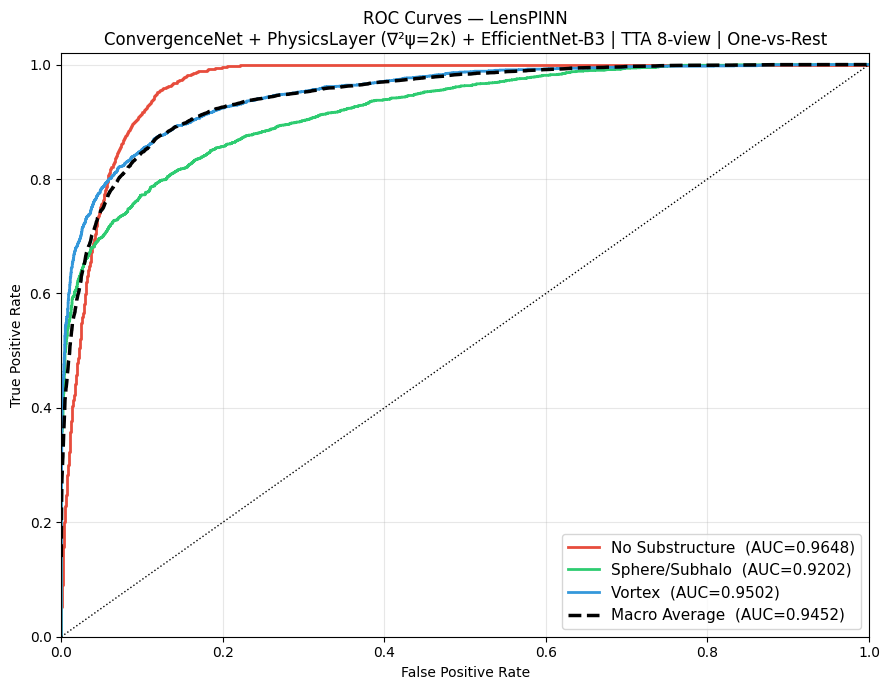


Per-class AUC (on val/):
         No Substructure: 0.9648
          Sphere/Subhalo: 0.9202
                  Vortex: 0.9502
           Macro Average: 0.9452


In [12]:
n  = CONFIG['num_classes']
lb = label_binarize(val_labels, classes=list(range(n)))
colors = ['#e74c3c','#2ecc71','#3498db']

fig, ax = plt.subplots(figsize=(9,7))
aucs, fpr_list = [], []

for i in range(n):
    fpr, tpr, _ = roc_curve(lb[:,i], val_probs[:,i])
    a = auc(fpr,tpr); aucs.append(a); fpr_list.append(fpr)
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f"{CONFIG['display_names'][i]}  (AUC={a:.4f})")

all_fpr  = np.unique(np.concatenate(fpr_list))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n):
    fpr, tpr, _ = roc_curve(lb[:,i], val_probs[:,i])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= n
macro_auc = auc(all_fpr, mean_tpr)
ax.plot(all_fpr, mean_tpr, 'k--', lw=2.5, label=f'Macro Average  (AUC={macro_auc:.4f})')
ax.plot([0,1],[0,1],'k:',lw=1)

ax.set(xlim=[0,1], ylim=[0,1.02],
       xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curves — LensPINN\n'
             'ConvergenceNet + PhysicsLayer (∇²ψ=2κ) + EfficientNet-B3 | TTA 8-view | One-vs-Rest')
ax.legend(loc='lower right', fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('roc_pinn.png', dpi=150); plt.show()

print('\nPer-class AUC (on val/):')
for name, a in zip(CONFIG['display_names'], aucs):
    print(f'  {name:>22}: {a:.4f}')
print(f'  {"Macro Average":>22}: {macro_auc:.4f}')

## 9. Visualise Physics Maps

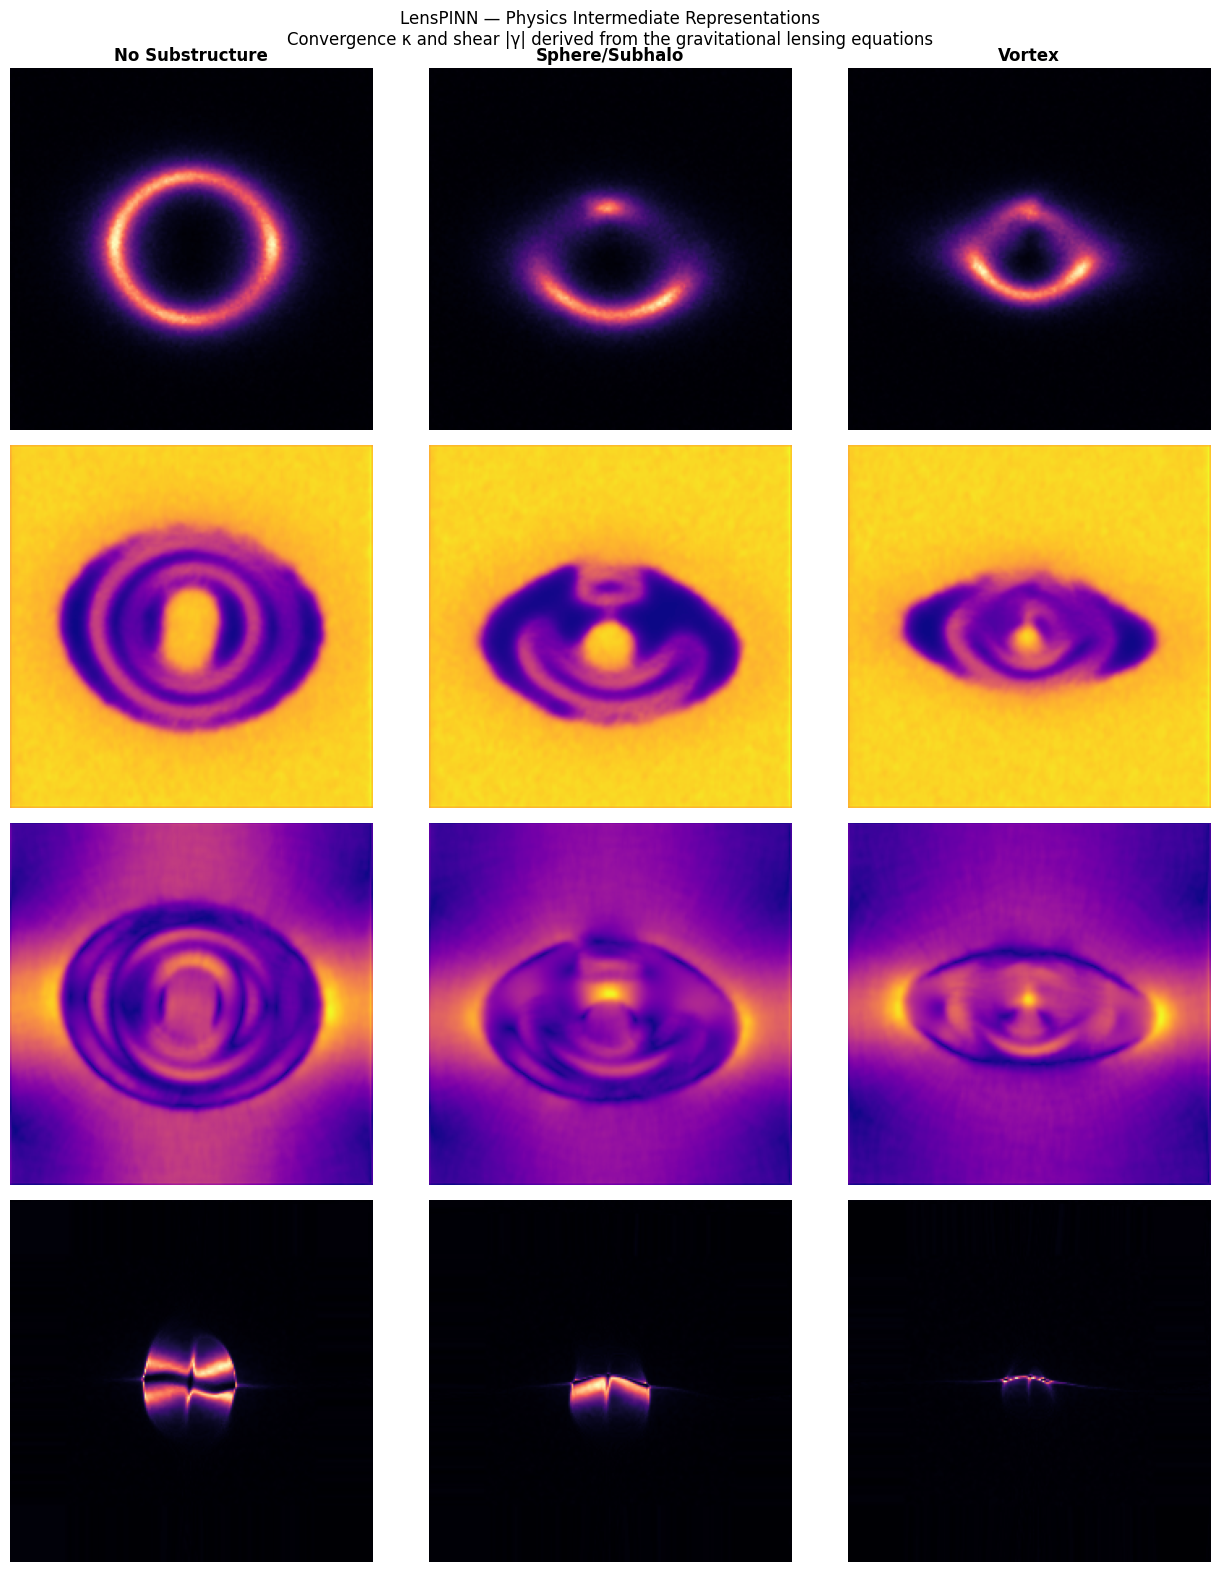

κ peaks indicate mass concentration; shear pattern distinguishes sphere vs vortex.


In [13]:
"""
For each class, visualise:
  Row 0: Input image
  Row 1: Predicted κ map (convergence = mass density)
  Row 2: Shear magnitude √(γ₁²+γ₂²)
  Row 3: Reconstructed source (via lens equation β=θ−α)

This figure shows the network has learned physically meaningful
intermediate representations, not just pixel statistics.
"""
model.eval()
ds_vis = LensDataset(tr_fps_all, tr_labs_all, CONFIG['img_size'], augment=False)

shown={}
for i in range(len(ds_vis)):
    lab = tr_labs_all[i]
    if lab not in shown: shown[lab] = i
    if len(shown) == CONFIG['num_classes']: break

fig, axes = plt.subplots(4, 3, figsize=(13, 16))
row_labels = ['Input Image', 'Predicted κ (Convergence)', 'Shear |γ|',
              'Reconstructed Source\n(β = θ − α)']

with torch.no_grad():
    for col, (lab, idx) in enumerate(sorted(shown.items())):
        img_n, img_r, _ = ds_vis[idx]
        img_n_b = img_n.unsqueeze(0).to(DEVICE)
        img_r_b = img_r.unsqueeze(0).to(DEVICE)
        _, src_recon, kappa_pred = model(img_n_b, img_r_b)

        phys_maps, _ = model.physics_layer(kappa_pred, img_r_b)
        gamma_mag = (phys_maps[0,1]**2 + phys_maps[0,2]**2).sqrt().cpu().numpy()

        img_disp = img_r.mean(0).numpy()
        kap_disp = kappa_pred[0,0].cpu().numpy()
        src_disp = src_recon[0].mean(0).cpu().numpy()

        for row, data in enumerate([img_disp, kap_disp, gamma_mag, src_disp]):
            cmap = 'magma' if row in (0,3) else 'plasma'
            axes[row,col].imshow(data, cmap=cmap, origin='lower')
            axes[row,col].axis('off')
            if row==0: axes[row,col].set_title(
                CONFIG['display_names'][lab], fontsize=12, fontweight='bold')
            if col==0: axes[row,col].set_ylabel(row_labels[row], fontsize=10)

fig.suptitle(
    'LensPINN — Physics Intermediate Representations\n'
    'Convergence κ and shear |γ| derived from the gravitational lensing equations',
    fontsize=12
)
plt.tight_layout()
plt.savefig('pinn_physics_maps.png', dpi=150)
plt.show()
print('κ peaks indicate mass concentration; shear pattern distinguishes sphere vs vortex.')

## 10. Loss Decomposition & Training History

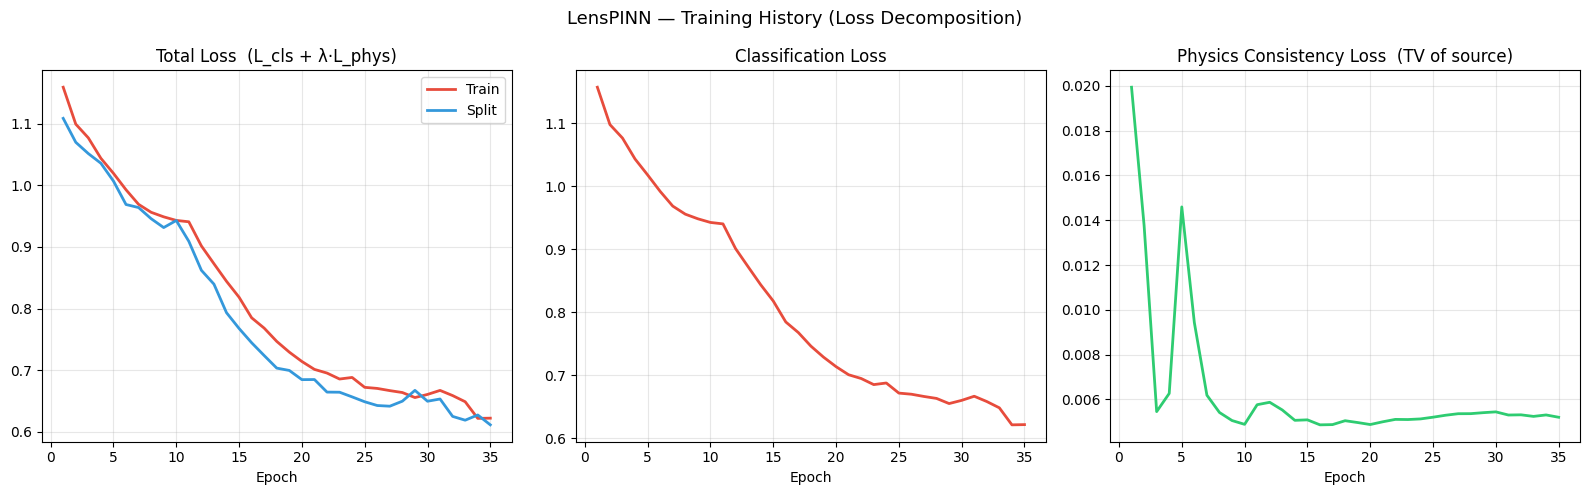


  Macro AUC (val/, TTA 8-view) : 0.9452
  Val Acc   (val/, TTA 8-view) : 0.8221


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ep = range(1, len(history['tr_loss'])+1)

axes[0].plot(ep, history['tr_loss'],  label='Train',       color='#e74c3c', lw=2)
axes[0].plot(ep, history['va_loss'],  label='Split',       color='#3498db', lw=2)
axes[0].set(title='Total Loss  (L_cls + λ·L_phys)', xlabel='Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['cls_loss'], color='#e74c3c', lw=2)
axes[1].set(title='Classification Loss', xlabel='Epoch')
axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['phy_loss'], color='#2ecc71', lw=2)
axes[2].set(title='Physics Consistency Loss  (TV of source)', xlabel='Epoch')
axes[2].grid(alpha=0.3)

fig.suptitle('LensPINN — Training History (Loss Decomposition)', fontsize=13)
plt.tight_layout()
plt.savefig('training_history_pinn.png', dpi=150)
plt.show()

print(f'\n{"="*55}')
print(f'  Macro AUC (val/, TTA 8-view) : {macro_auc:.4f}')
print(f'  Val Acc   (val/, TTA 8-view) : {val_acc:.4f}')
print(f'{"="*55}')